In [22]:
from sklearn.datasets import fetch_openml
import numpy as np
mnist = fetch_openml('mnist_784', as_frame=False)
print(type(mnist))

<class 'sklearn.utils._bunch.Bunch'>


In [23]:
X,y = mnist.data , mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [24]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

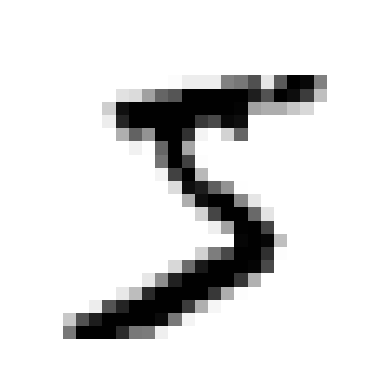

5


In [25]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image,cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

print(y[0])


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

In [27]:
X_train, X_test, y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")


In [28]:
sgd_clf = SGDClassifier()
sgd_clf.fit(X_train,y_train_5)

print(sgd_clf.predict([some_digit]))

[ True]


In [29]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring="accuracy")
print(score)

In [31]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
score = cross_val_score(dummy,X_train,y_train_5,cv=3,scoring="accuracy")
print(score)

[0.90965 0.90965 0.90965]


In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)
conf_matrix = confusion_matrix(y_train_5,y_train_pred)
conf_matrix

array([[54196,   383],
       [ 1898,  3523]])

In [37]:
from sklearn.metrics import precision_score,recall_score,f1_score
precision_score(y_train_5,y_train_pred)

0.9019457245263697

In [38]:
recall_score(y_train_5,y_train_pred)

0.6498800959232613

In [39]:
f1_score(y_train_5,y_train_pred)

0.7554411922375898

In [40]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([22.71616476])

In [42]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [43]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [44]:
y_scores = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method = "decision_function")
y_scores

array([  -655.18748994, -29222.53246092, -28814.08116073, ...,
         8080.79289808,  -8891.47199301, -15403.02151534], shape=(60000,))

In [45]:
from sklearn.metrics import precision_recall_curve
precision,recall, thresholds = precision_recall_curve(y_train_5,y_scores)

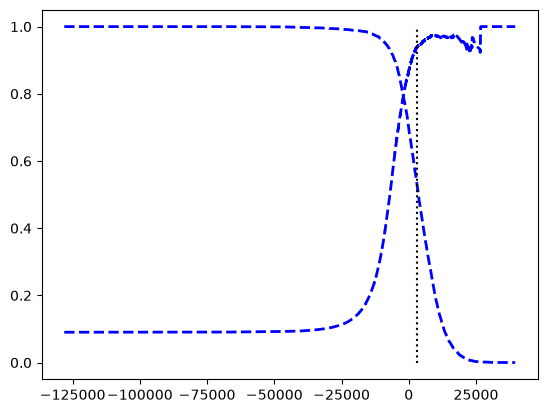

In [47]:
plt.plot(thresholds,precision[:-1],"b--",label = 'Precision',linewidth=2)
plt.plot(thresholds,recall[:-1],"b--",label = 'Precision',linewidth=2)
plt.vlines(threshold,0,1.0,"k","dotted")
plt.show()

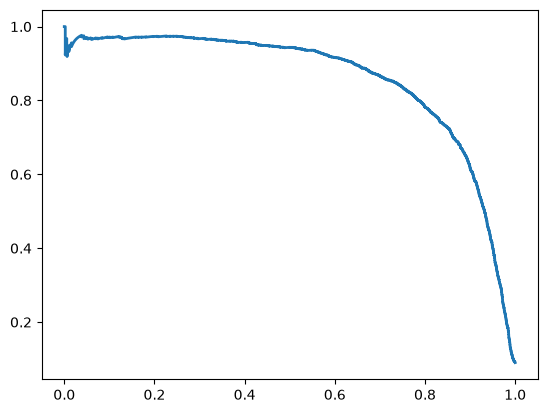

In [48]:
plt.plot(recall,precision,linewidth=2,label = "Precision/Recall curve")
plt.show()

In [49]:
idx_for_90_precision = (precision >= 90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(-128083.19393135597)

In [50]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
print(precision_score(y_train_5,y_train_pred_90))
recall_at_90_precision = recall_score(y_train_5,y_train_pred_90)
recall_at_90_precision

0.09035


1.0

In [52]:
from sklearn.metrics import roc_curve
fpr,tpr, thresholds = roc_curve(y_train_5,y_scores)

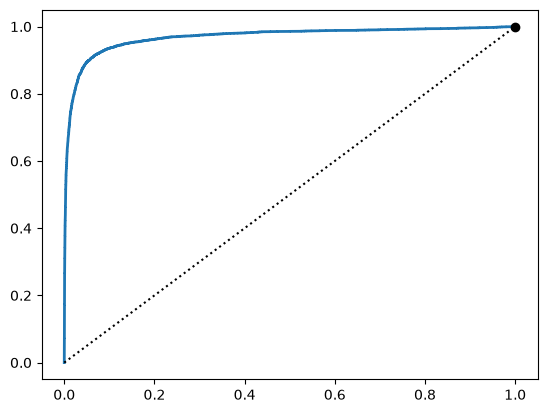

In [53]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.show()

In [54]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9686644115824128

In [55]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [56]:
y_proba_forest = cross_val_predict(forest_clf,X_train,y_train_5,cv =3, method = "predict_proba" )
y_scores_forest = y_proba_forest[:,-1]
fprecision,frecall,fthresholds = precision_recall_curve(y_train_5,y_scores_forest)

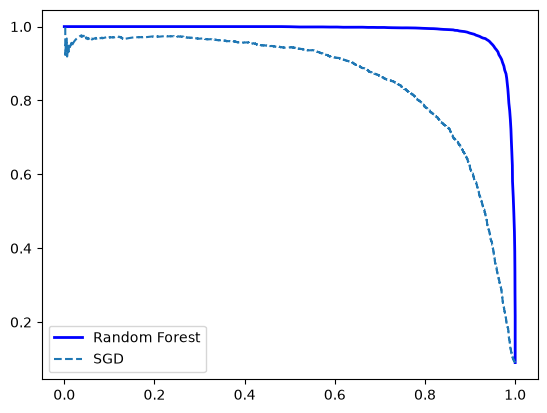

In [58]:
plt.plot(frecall,fprecision,"b-",linewidth= 2,label = "Random Forest")
plt.plot(recall,precision,"--",label = "SGD")
plt.legend()
plt.show()

In [59]:
y_train_pred_forest = y_proba_forest[:,1] >= 0.5
f1_score(y_train_5,y_train_pred_forest)

0.9270445185330457

In [60]:
roc_auc_score(y_train_5,y_scores_forest)

0.9983296721818179